# Proyecto MOTHER - 2_Ingenieria_Caracteristicas.ipynb

## Misión: Enriquecimiento y Transformación para Modelado

Este notebook inicia leyendo el dataset limpio generado en la etapa de preparación (`datos_integrados.csv`).  
Procede con la ingeniería de características necesarias para el modelado.  
Realiza el análisis exploratorio con gráficos y análisis estadístico para comprender las variables claves.  
Calcula la matriz de asociación categórica (V de Cramér) para evaluar relaciones entre variables nominales.  
Finalmente, codifica las variables categóricas con Label Encoding para preparar los datos para los modelos predictivos y exporta el dataset preparado (`datos_modelo.csv`).


In [ ]:
# 2_ingenieria_caracteristicas.ipynb - Bloque 1: Importaciones y configuración de logging

import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as ss
from pathlib import Path

# 1. Rutas para enviar el logger a la carpeta central
BASE_DIR = Path.cwd().parent
CARPETA_LOGS = BASE_DIR / 'reportes'
CARPETA_LOGS.mkdir(exist_ok=True)
ruta_log = CARPETA_LOGS / 'mother_pipeline.log'

# 2. Configuración: filemode='a' para agregar debajo del registro anterior
logging.basicConfig(
    filename=str(ruta_log),
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='a'
)
logger = logging.getLogger()

logger.info("Inicio del notebook 2_Ingenieria_Caracteristicas")


In [3]:
# 2_ingenieria_caracteristicas.ipynb - Bloque 2: Carga del dataset limpio

from pathlib import Path

logger.info("Cargando dataset limpio 'datos_integrados.csv' desde carpeta data/processed...")

BASE_DIR = Path.cwd().parent  # asumiendo ejecutas el notebook desde inputs/
processed_dir = BASE_DIR / 'data' / 'processed'
file_path = processed_dir / 'datos_integrados.csv'

df = pd.read_csv(file_path)

logger.info(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

# Mostrar primeras filas para inspección rápida (podrías comentar esto en producción)
display(df.head())


,id_siniestro,fecha_siniestro,anio_siniestro_x,modo_desplazamiento_victima_x,sexo_victima,edad_victima,gravedad_victima,rol_victima,fecha_fallecimiento_victima,numero_total_de_victimas,...,rango_horario,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,modo_desplazamiento_victima_y,contraparte_siniestro
0,LC-2019-0000647,2019-01-01,2019,MOTO,M,54.0,GRAVE,NaN,NaN,1,...,18.0,DE LOS CONSTITUYENTES AV. y HABANA,COMUNA 12,AVENIDA,POINT (97510.27137648081406951 105087.83369881...,-58.490436,-34.583403,MOTO-AUTO,MOTO,AUTO
1,LC-2019-0000600,2019-01-01,2019,NaN,F,1.0,LEVE,NaN,NaN,1,...,19.0,NaN,COMUNA 1,NaN,POINT (108178.21037640585564077 104229.8809107...,-58.374154,-34.591108,PEATON-TRANSPORTE PUBLICO,PEATON,TRANSPORTE PUBLICO
2,LC-2019-0000136,2019-01-01,2019,NaN,F,21.0,LEVE,NaN,NaN,2,...,8.0,NaN,COMUNA 15,NaN,POINT (102193.35632690557395108 104565.9966998...,-58.439392,-34.588108,MOTO-AUTO,MOTO,AUTO
3,LC-2019-0000082,2019-01-01,2019,NaN,F,32.0,LEVE,NaN,NaN,4,...,4.0,NaN,COMUNA 3,NaN,POINT (105968.98286849579017144 102737.1734686...,-58.398225,-34.604579,AUTO-TRANSPORTE PUBLICO,AUTO,TRANSPORTE PUBLICO
4,LC-2019-0000194,2019-01-01,2019,NaN,F,33.0,LEVE,NaN,NaN,1,...,7.0,NaN,COMUNA 9,NaN,POINT (94030.76669932194636203 97681.071761248...,-58.528413,-34.650156,AUTO-CAMION,AUTO,CAMION


### Definición de Módulos Analíticos y de Visualización


Se definen tres tipos de herramientas:
1. **Funciones Univariadas:** Para explorar la distribución individual de características clave (ej. frecuencia de accidentes por comuna o edad).
2. **Funciones Bivariadas:** Para analizar la relación entre cualquier variable predictora y nuestra variable objetivo (`gravedad_victima`).
3. **Funciones Multivariadas (Estadísticas):** Implementación del cálculo de la V de Cramér para medir el nivel de asociación matemática entre variables categóricas, vital para modelos de árboles de decisión.

### 2.2 Análisis Univariado: Entendiendo las Distribuciones
En esta sección, utilizamos nuestra función modular para observar el comportamiento individual de las variables más críticas del dataset. Esto nos permite identificar desbalanceos de clases (especialmente en nuestra variable objetivo `gravedad_victima`) y entender los volúmenes de datos por comuna o tipo de vehículo.

In [4]:
def analizar_variable_numerica(df, columna):
    """
    Crea un panel con un histograma y un boxplot para analizar
    la distribución y detectar outliers en una variable numérica.
    """
    # Filtramos los nulos solo para el gráfico, para que no tire error
    datos_limpios = df[columna].dropna()

    # Configuramos la figura con dos subgráficos (1 fila, 2 columnas)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Histograma en el primer eje
    sns.histplot(datos_limpios, bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {columna}')
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel('Frecuencia')

    # 2. Boxplot en el segundo eje para ver outliers
    sns.boxplot(x=datos_limpios, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot de {columna} (Detección de Outliers)')
    axes[1].set_xlabel(columna)

    plt.tight_layout()
    plt.show()

def analizar_variables_categoricas(df, columnas_categoricas):
    """
    Genera gráficos de barras horizontales para ver la frecuencia
    de las categorías en las variables seleccionadas.
    """
    for col in columnas_categoricas:
        plt.figure(figsize=(10, 4))
        # Usamos countplot para contar la frecuencia de cada categoría
        sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Frecuencia de categorías en: {col}')
        plt.xlabel('Cantidad')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

--- ANÁLISIS DE LA EDAD DE LAS VÍCTIMAS ---


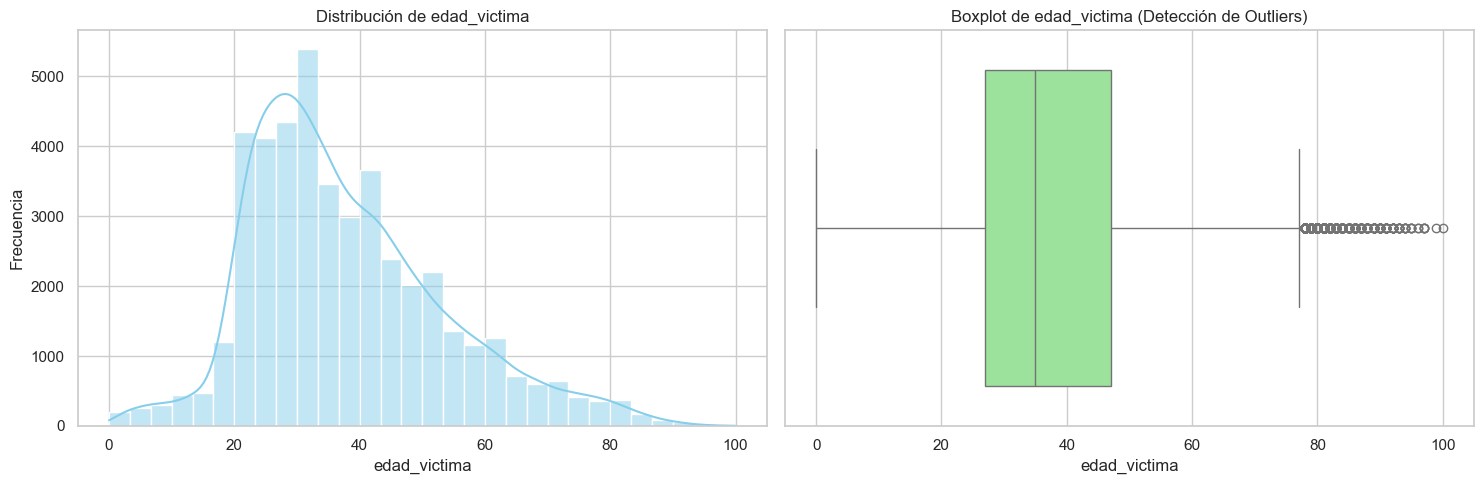


--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---


C:\Users\USER\AppData\Local\Temp\ipykernel_20124\2141523696.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


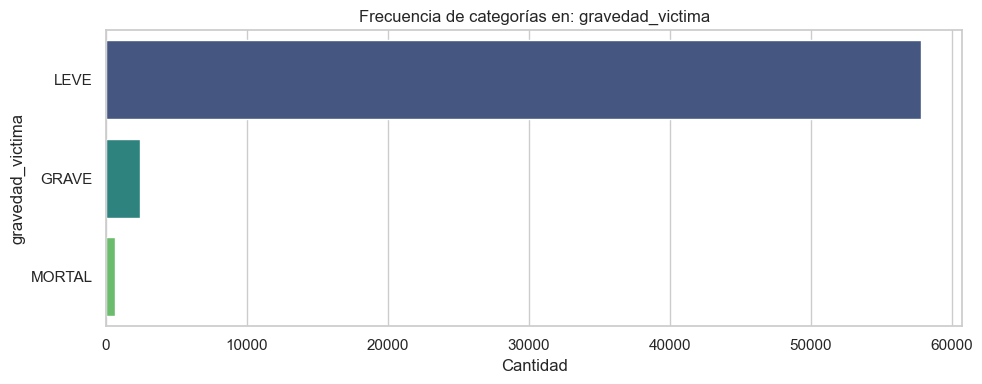

C:\Users\USER\AppData\Local\Temp\ipykernel_20124\2141523696.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


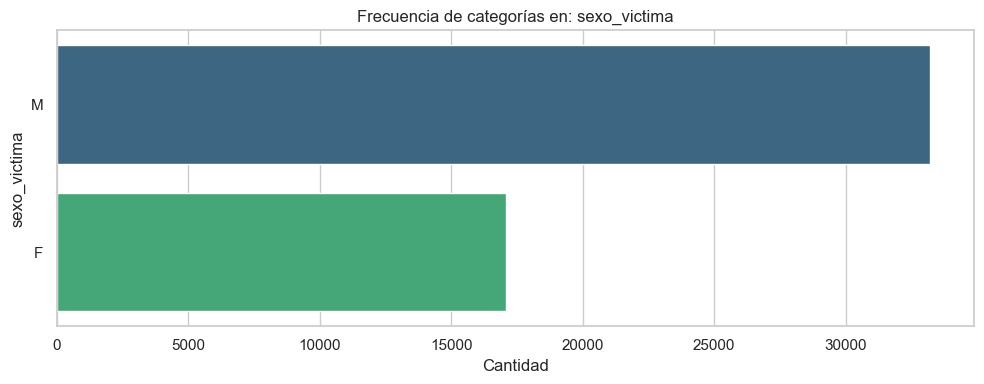

C:\Users\USER\AppData\Local\Temp\ipykernel_20124\2141523696.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


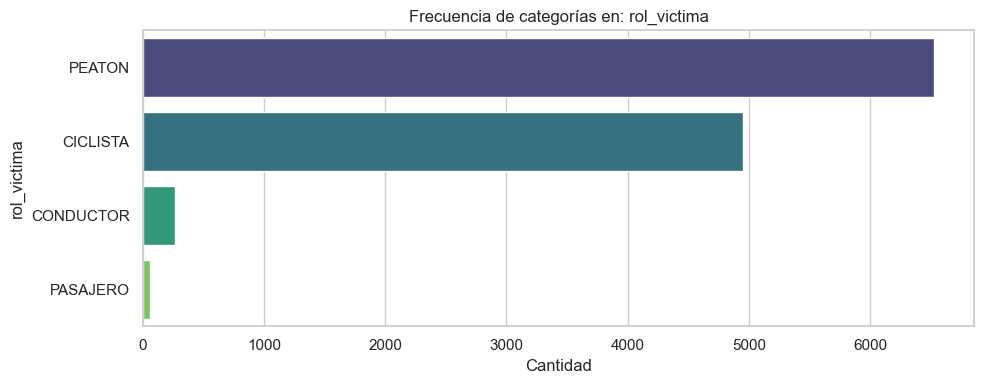

C:\Users\USER\AppData\Local\Temp\ipykernel_20124\2141523696.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


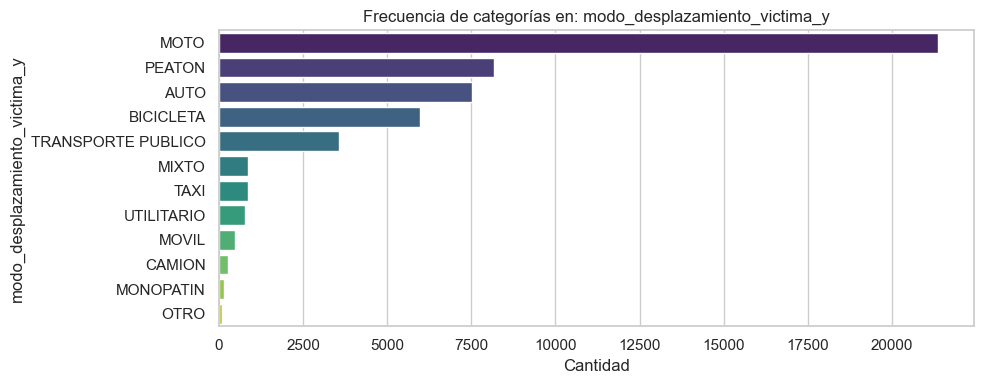

C:\Users\USER\AppData\Local\Temp\ipykernel_20124\2141523696.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


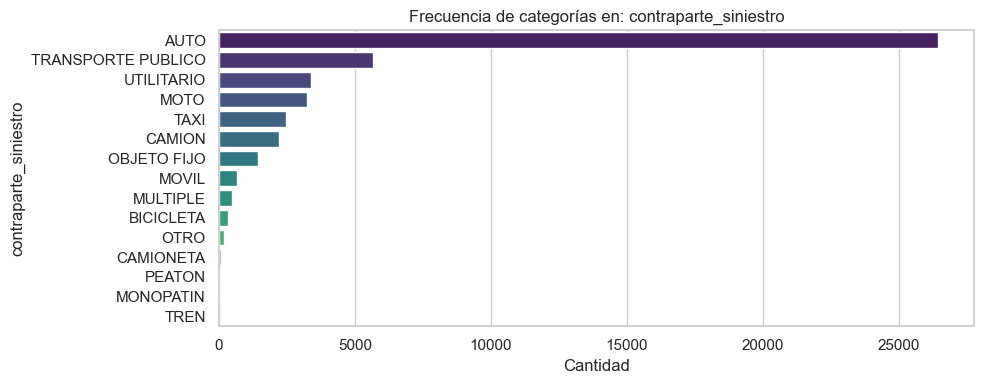

C:\Users\USER\AppData\Local\Temp\ipykernel_20124\2141523696.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


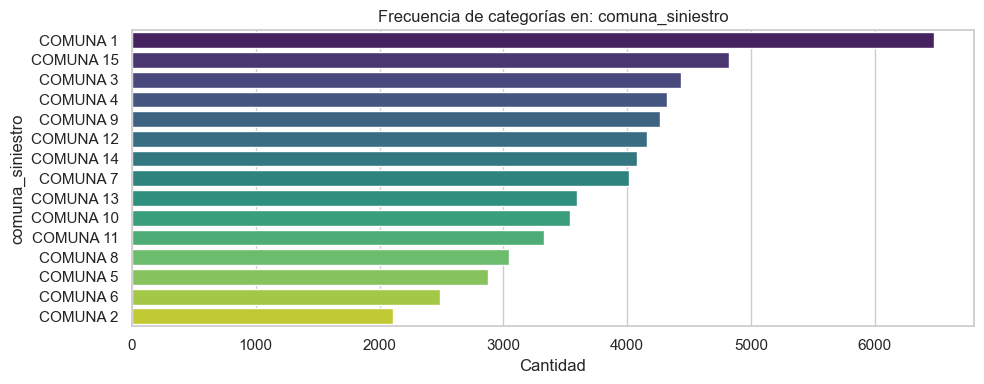

C:\Users\USER\AppData\Local\Temp\ipykernel_20124\2141523696.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], data=df, order=df[col].value_counts().index, palette='viridis')


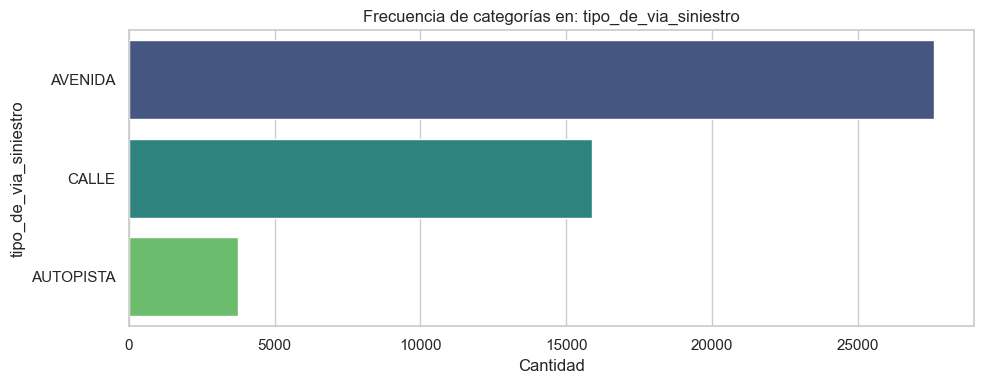

In [5]:
# Configuración estética global para los gráficos
sns.set_theme(style="whitegrid")

# 1. Análisis de Outliers y Distribución (Numérica)
print("--- ANÁLISIS DE LA EDAD DE LAS VÍCTIMAS ---")
analizar_variable_numerica(df, 'edad_victima')

# 2. Análisis de Variables Categóricas Clave
print("\n--- ANÁLISIS DE VARIABLES CATEGÓRICAS ---")
columnas_a_graficar = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima_y','contraparte_siniestro','comuna_siniestro', 'tipo_de_via_siniestro']

analizar_variables_categoricas(df, columnas_a_graficar)

### 2.3 Análisis Bivariado: Relación con la Variable Objetivo
Una vez entendidas las distribuciones individuales, cruzamos nuestras variables independientes con la gravedad del siniestro. Buscamos responder preguntas de negocio: ¿Hay vehículos más propensos a accidentes mortales? ¿El riesgo varía según la franja horaria?

In [6]:
def bivariado_categoricas_vs_target(df, columnas_cat, target):
    """
    Genera gráficos de barras agrupadas para comparar variables categóricas
    contra la variable objetivo.
    """
    for col in columnas_cat:
        if col != target:  # Evitamos cruzar la variable objetivo consigo misma
            plt.figure(figsize=(12, 6))
            # Usamos 'hue' para dividir las barras según la gravedad
            sns.countplot(data=df, y=col, hue=target, palette='Set2')
            plt.title(f'Relación entre {col} y {target}')
            plt.xlabel('Cantidad de Víctimas')
            plt.ylabel(col)
            plt.legend(title='Gravedad', loc='lower right')
            plt.tight_layout()
            plt.show()

def bivariado_numerica_vs_target(df, col_num, target):
    """
    Genera un boxplot para ver cómo se distribuye una variable numérica
    en cada una de las categorías de la variable objetivo.
    """
    plt.figure(figsize=(10, 6))
    # El boxplot nos mostrará si la mediana de edad cambia según si es leve, grave o mortal
    sns.boxplot(data=df, x=target, y=col_num, palette='Set3')
    plt.title(f'Distribución de {col_num} según {target}')
    plt.xlabel('Gravedad de la Víctima')
    plt.ylabel(col_num)
    plt.tight_layout()
    plt.show()

--- ANÁLISIS BIVARIADO: CATEGÓRICAS VS GRAVEDAD ---


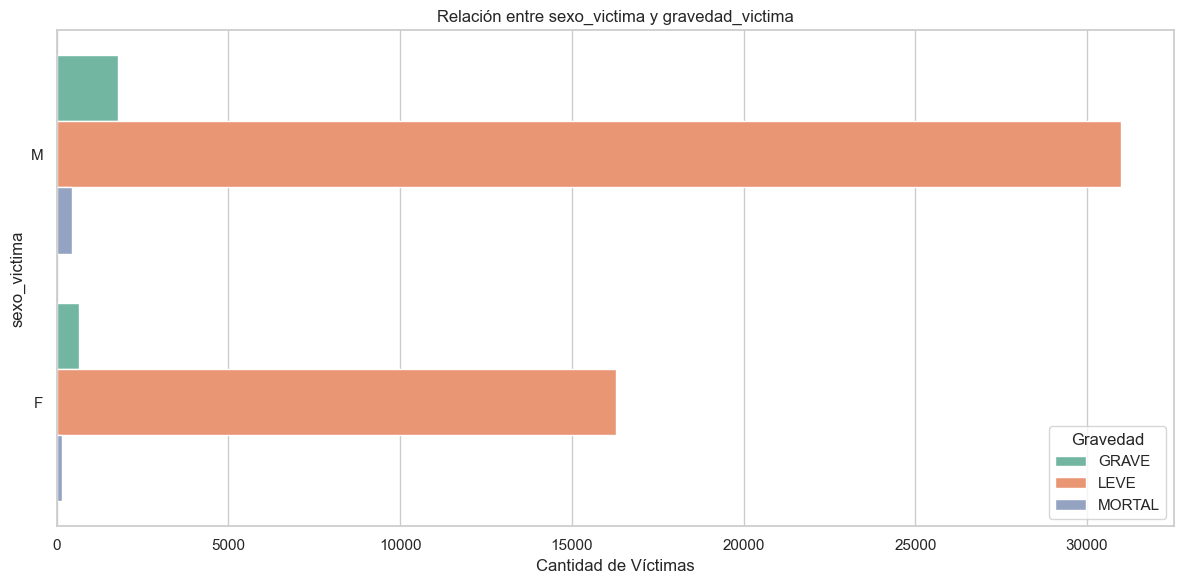

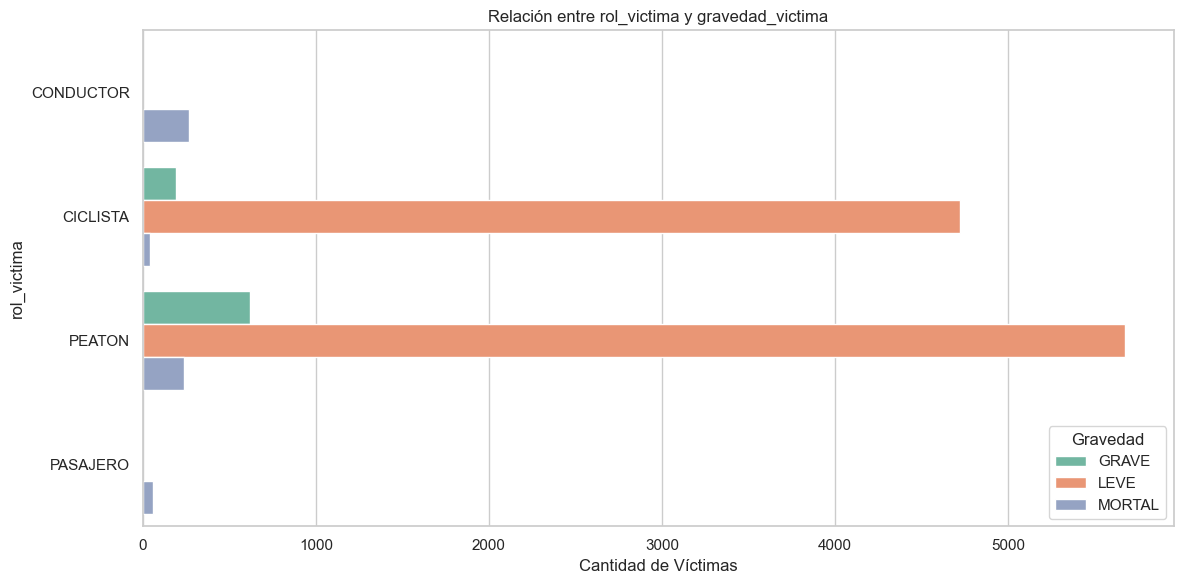

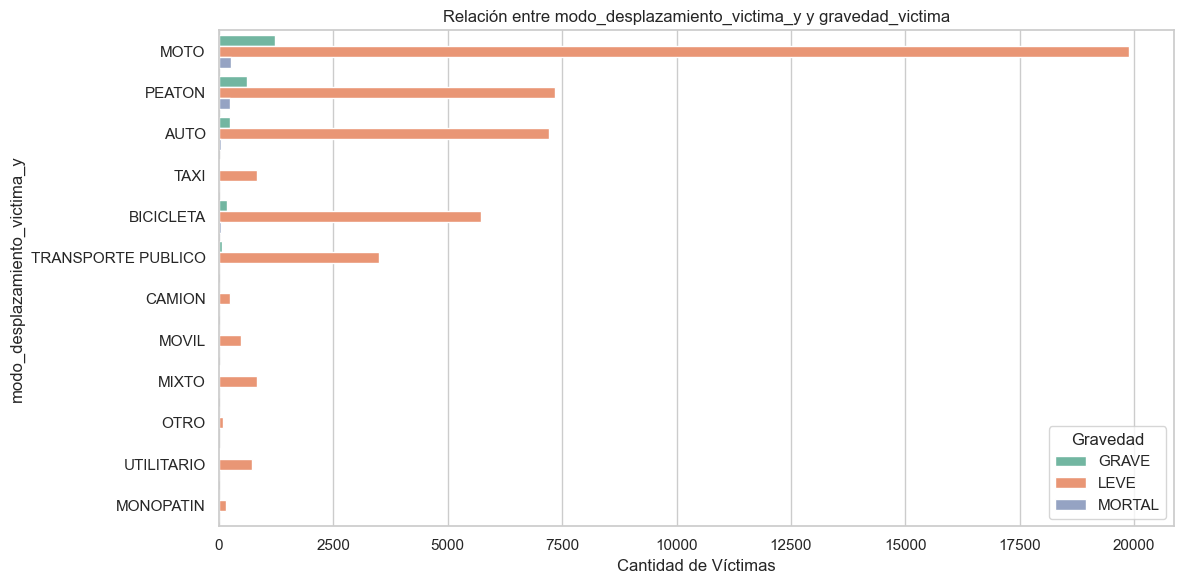


--- ANÁLISIS BIVARIADO: EDAD VS GRAVEDAD ---


C:\Users\USER\AppData\Local\Temp\ipykernel_20124\4069321421.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=col_num, palette='Set3')


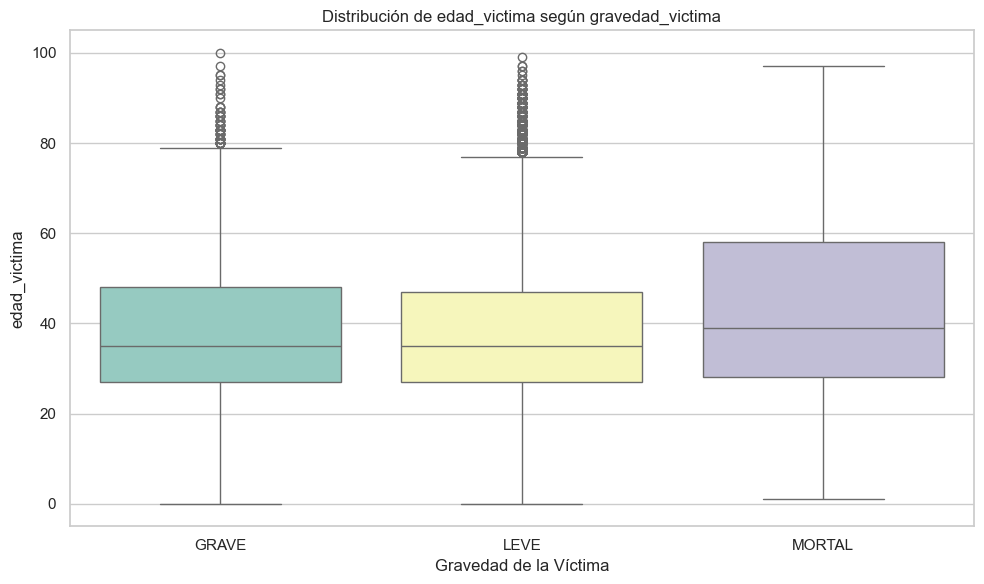

In [7]:
sns.set_theme(style="whitegrid")

print("--- ANÁLISIS BIVARIADO: CATEGÓRICAS VS GRAVEDAD ---")
# Usamos la lista de columnas que ya teníamos
columnas_cat = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima_y']
target_col = 'gravedad_victima'

bivariado_categoricas_vs_target(df, columnas_cat, target_col)

print("\n--- ANÁLISIS BIVARIADO: EDAD VS GRAVEDAD ---")
bivariado_numerica_vs_target(df, 'edad_victima', target_col)

### 2.3 Análisis Bivariado: Series temporales
Buscamos en este apartado identificar tendencias a lo largo del tiempo, tanto a nivel años, meses, como dias y hasta horarios

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import pandas as pd

def analizar_tendencias_temporales(df, target):
    """
    Analiza la evolución temporal de los accidentes a nivel histórico,
    por mes del año y por día de la semana.
    """
    try:
        df_temp = df.copy()

        
        # Forzamos la conversión de la columna a formato fecha (datetime)
        # errors='coerce' transformará cualquier texto mal formado en NaT (nulo temporal)
        df_temp['fecha_siniestro'] = pd.to_datetime(df_temp['fecha_siniestro'], errors='coerce')
        
        # Descartamos nulos en la fecha para evitar errores matemáticos posteriores
        df_temp = df_temp.dropna(subset=['fecha_siniestro'])

        # 1. Extraemos características temporales útiles usando .dt (ahora sí funcionará)
        df_temp['año_mes'] = df_temp['fecha_siniestro'].dt.to_period('M').astype(str)

        dias = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
        df_temp['dia_semana'] = df_temp['fecha_siniestro'].dt.dayofweek.map(dias)

        meses = {1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril', 5: 'Mayo', 6: 'Junio',
                 7: 'Julio', 8: 'Agosto', 9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'}
        df_temp['mes'] = df_temp['fecha_siniestro'].dt.month.map(meses)

        # --- Gráfico 1: Evolución Histórica (Línea de tiempo) ---
        plt.figure(figsize=(14, 6))
        evolucion = df_temp.groupby(['año_mes', target]).size().reset_index(name='cantidad')

        ax = sns.lineplot(data=evolucion, x='año_mes', y='cantidad', hue=target, marker='o', palette='Set2', linewidth=2)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=15))

        plt.title('Evolución Temporal de Siniestros Viales por Gravedad', fontsize=14)
        plt.xlabel('Año - Mes')
        plt.ylabel('Cantidad de Víctimas')
        plt.xticks(rotation=45)
        plt.legend(title='Gravedad')
        plt.tight_layout()
        plt.show()

        # --- Gráfico 2: Accidentes por Mes del Año (Estacionalidad) ---
        plt.figure(figsize=(12, 6))
        orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                       'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

        sns.countplot(data=df_temp, x='mes', hue=target, order=orden_meses, palette='Set2')
        plt.title('Distribución de Siniestros por Mes del Año', fontsize=14)
        plt.xlabel('Mes')
        plt.ylabel('Cantidad de Víctimas')
        plt.xticks(rotation=45)
        plt.legend(title='Gravedad', loc='upper right')
        plt.tight_layout()
        plt.show()

        # --- Gráfico 3: Accidentes por Día de la Semana ---
        plt.figure(figsize=(12, 6))
        orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

        sns.countplot(data=df_temp, x='dia_semana', hue=target, order=orden_dias, palette='Set2')
        plt.title('Distribución de Siniestros por Día de la Semana', fontsize=14)
        plt.xlabel('Día de la Semana')
        plt.ylabel('Cantidad de Víctimas')
        plt.legend(title='Gravedad', loc='upper right')
        plt.tight_layout()
        plt.show()
        
        logger.info("Análisis de tendencias temporales generado exitosamente.")
        
    except Exception as e:
        logger.error(f"Fallo durante la generación del análisis temporal: {e}")

--- ANÁLISIS TEMPORAL DE LOS SINIESTROS ---


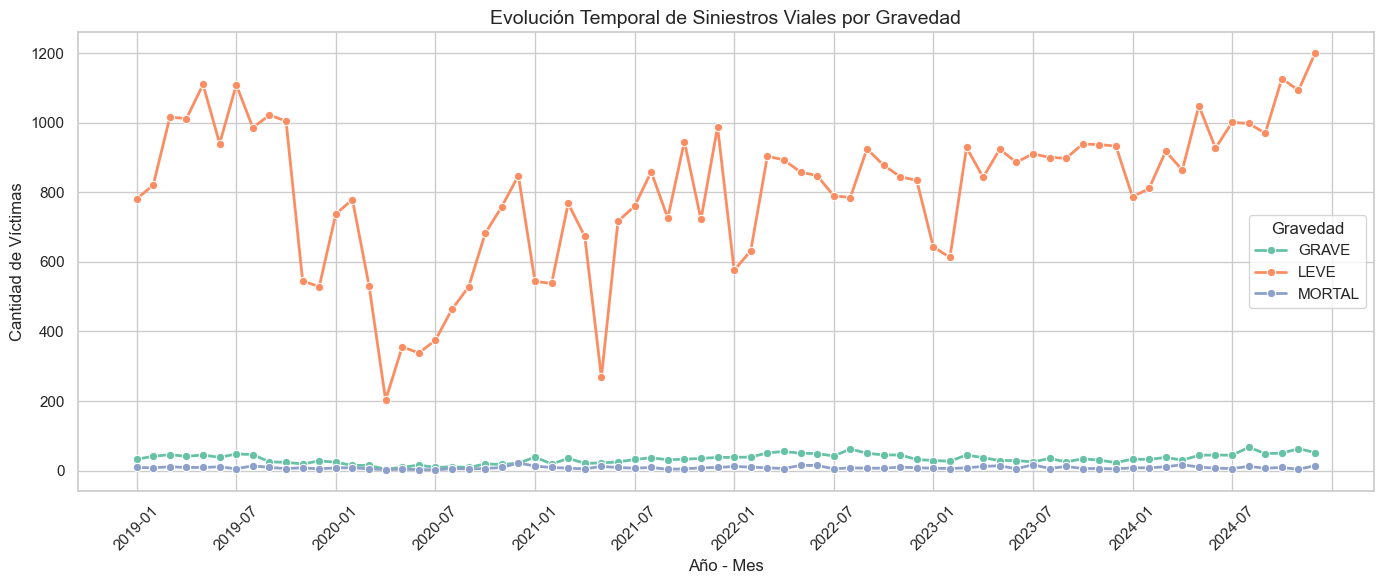

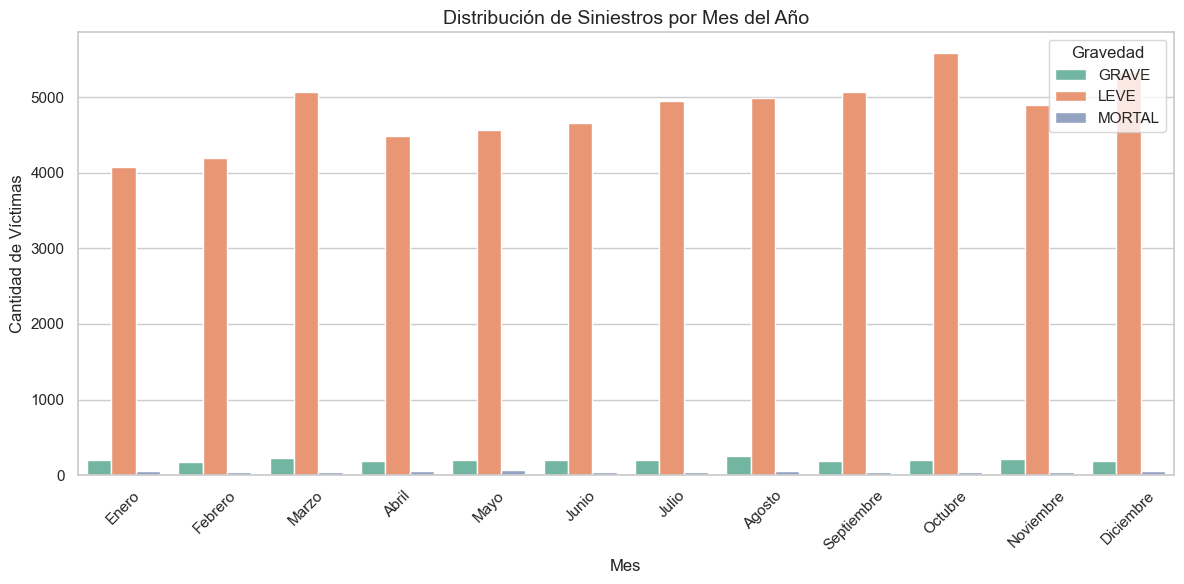

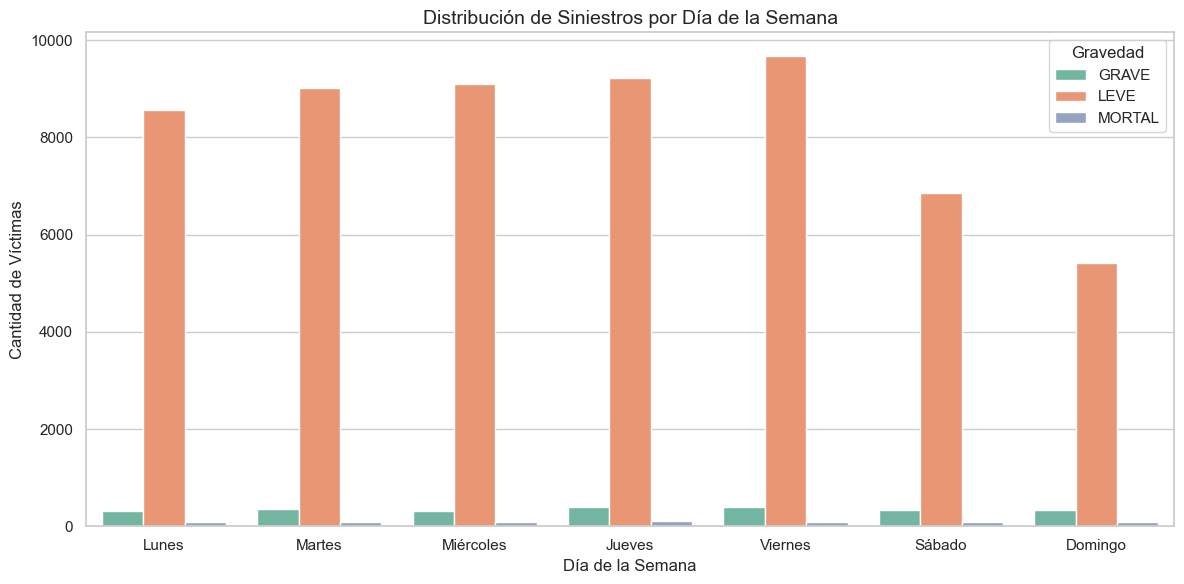

In [9]:
print("--- ANÁLISIS TEMPORAL DE LOS SINIESTROS ---")
analizar_tendencias_temporales(df, 'gravedad_victima')

El análisis temporal de los siniestros viales a menudo sufre de la "ilusión de volumen": asumimos que las horas con más tráfico (horas pico) son las más mortales, cuando en realidad solo acumulan choques leves por congestión.

Para desmitificar esto, cruzaremos los días de la semana con las horas del día, comparando el comportamiento del volumen total de accidentes frente a los siniestros estrictamente MORTALES.

--- ANÁLISIS TEMPORAL: VOLUMEN GENERAL VS. FATALIDAD ---


C:\Users\USER\AppData\Local\Temp\ipykernel_20124\3243397896.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  matriz_horaria = df_graficos.groupby(['nombre_dia', 'rango_horario']).size().unstack(fill_value=0)


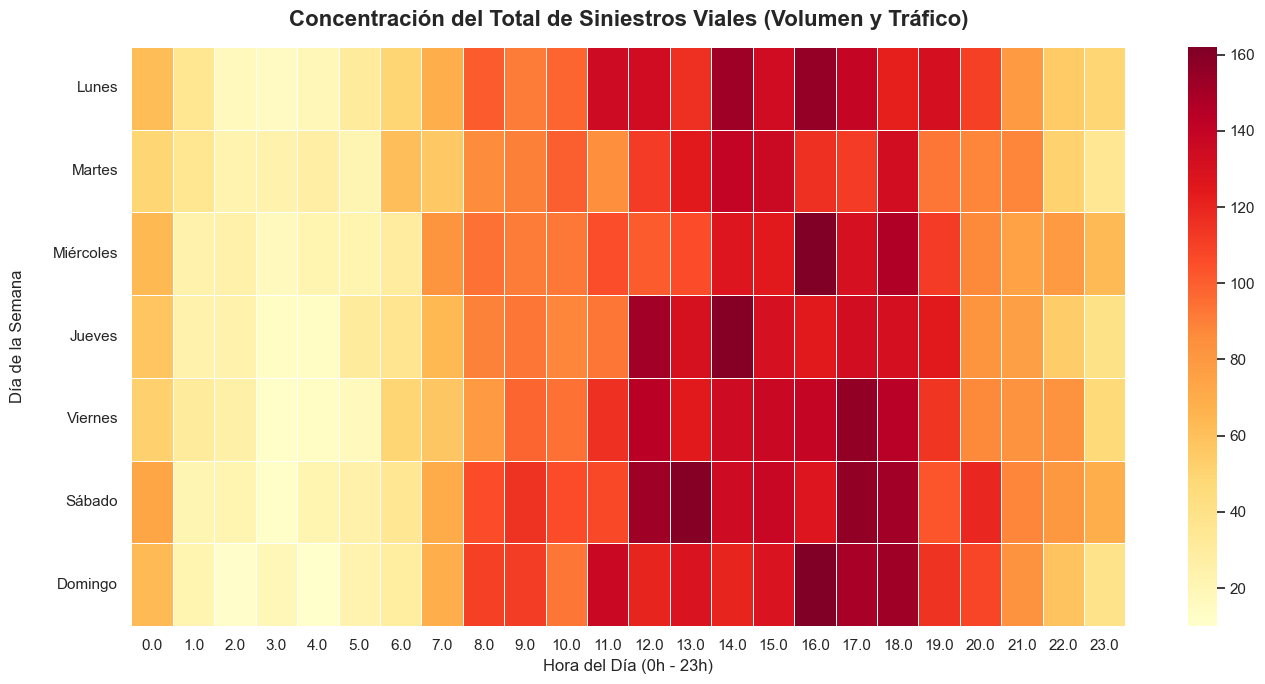

C:\Users\USER\AppData\Local\Temp\ipykernel_20124\3243397896.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  matriz_mortal_agrupada = df_mortales.groupby(['nombre_dia', 'franja_horaria']).size().unstack(fill_value=0)


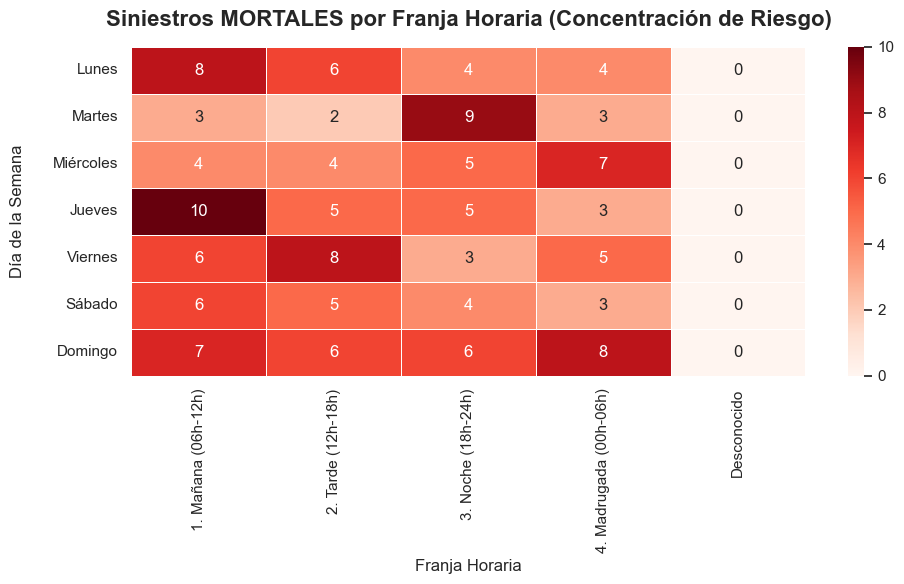

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- ANÁLISIS TEMPORAL: VOLUMEN GENERAL VS. FATALIDAD ---")

# ==========================================
# 1. PREPARACIÓN DE DATOS (Se hace una sola vez)
# ==========================================
df_graficos = df.copy()

# A. Mapeo de días de la semana
mapa_dias = {
    7: 'Lunes', 1: 'Martes', 2: 'Miércoles',
    3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'
}
df_graficos['nombre_dia'] = df_graficos['dia_siniestro'].map(mapa_dias)
orden_semana = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df_graficos['nombre_dia'] = pd.Categorical(df_graficos['nombre_dia'], categories=orden_semana, ordered=True)

# B. Creación de franjas horarias
def categorizar_franja_horaria(hora):
    if pd.isna(hora):
        return 'Desconocido'
    hora = int(hora)
    if 6 <= hora < 12:
        return '1. Mañana (06h-12h)'
    elif 12 <= hora < 18:
        return '2. Tarde (12h-18h)'
    elif 18 <= hora < 24:
        return '3. Noche (18h-24h)'
    else:
        return '4. Madrugada (00h-06h)'

df_graficos['franja_horaria'] = df_graficos['rango_horario'].apply(categorizar_franja_horaria)

# ==========================================
# 2. GRÁFICO 1: VOLUMEN TOTAL (24 HORAS)
# ==========================================
matriz_horaria = df_graficos.groupby(['nombre_dia', 'rango_horario']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(matriz_horaria, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('Concentración del Total de Siniestros Viales (Volumen y Tráfico)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hora del Día (0h - 23h)', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12, labelpad=20)
plt.yticks(rotation=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ==========================================
# 3. GRÁFICO 2: FATALIDAD AISLADA (FRANJAS AGRUPADAS)
# ==========================================
df_mortales = df_graficos[df_graficos['gravedad_victima'] == 'MORTAL']
matriz_mortal_agrupada = df_mortales.groupby(['nombre_dia', 'franja_horaria']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(matriz_mortal_agrupada, cmap='Reds', linewidths=0.5, annot=True, fmt="d")
plt.title('Siniestros MORTALES por Franja Horaria (Concentración de Riesgo)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Franja Horaria', fontsize=12)
plt.ylabel('Día de la Semana', fontsize=12, labelpad=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.4 Análisis Multivariado: Matriz de Asociación (V de Cramér)
Para evitar la multicolinealidad (variables que explican lo mismo y confunden al modelo), evaluamos la asociación matemática entre todas nuestras variables categóricas utilizando el coeficiente V de Cramér. Valores cercanos a 1 indican una asociación perfecta, mientras que valores cercanos a 0 indican independencia.

In [11]:
def calcular_v_cramer(x, y):
    """Calcula el estadístico V de Cramér con corrección de sesgo."""
    matriz_confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(matriz_confusion)[0]
    n = matriz_confusion.sum().sum()
    phi2 = chi2 / n
    r, k = matriz_confusion.shape

    # Corrección de sesgo para V de Cramér
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    denominador = min((kcorr-1), (rcorr-1))
    if denominador == 0:
        return 0.0
    return np.sqrt(phi2corr / denominador)

def generar_heatmap_cramer(df, columnas_cat):
    """
    Genera una matriz de asociación para variables estrictamente nominales.
    """
    # SOLUCIÓN: Convertimos temporalmente a tipo 'object' para que fillna no falle
    # con las columnas de tipo 'category'
    df_cat = df[columnas_cat].astype(object).fillna('Desconocido')

    n = len(columnas_cat)
    matriz_cramer = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            matriz_cramer[i, j] = calcular_v_cramer(df_cat[columnas_cat[i]], df_cat[columnas_cat[j]])

    df_cramer_results = pd.DataFrame(matriz_cramer, index=columnas_cat, columns=columnas_cat)

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cramer_results, annot=True, cmap='Blues', fmt=".2f", vmin=0, vmax=1, linewidths=0.5)
    plt.title("Asociación Categórica (V de Cramér)")
    plt.tight_layout()
    plt.show()

--- ANÁLISIS DE CORRELACIÓN AVANZADO ---

2. Ejecutando V de Cramér (Enfoque Nominal)...


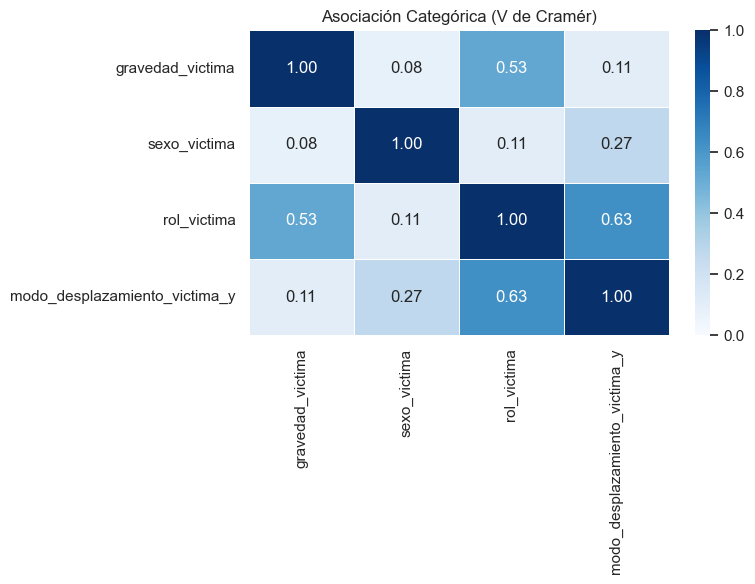

In [12]:
print("--- ANÁLISIS DE CORRELACIÓN AVANZADO ---")
columnas_cat = ['gravedad_victima', 'sexo_victima', 'rol_victima', 'modo_desplazamiento_victima_y']
target_col = 'gravedad_victima'

print("\n2. Ejecutando V de Cramér (Enfoque Nominal)...")
generar_heatmap_cramer(df, columnas_cat)

Agregamos la columna franja horaria para luego usarla en los modelos predictivos.

In [13]:
def categorizar_franja_horaria(hora):
    if pd.isna(hora):
        return 'Desconocido'
    hora = int(hora)
    if 6 <= hora < 12:
        return '1. Mañana (06h-12h)'
    elif 12 <= hora < 18:
        return '2. Tarde (12h-18h)'
    elif 18 <= hora < 24:
        return '3. Noche (18h-24h)'
    else:
        return '4. Madrugada (00h-06h)'

# 2. La aplicamos PERMANENTEMENTE a tu dataframe principal
df['franja_horaria'] = df['rango_horario'].apply(categorizar_franja_horaria)

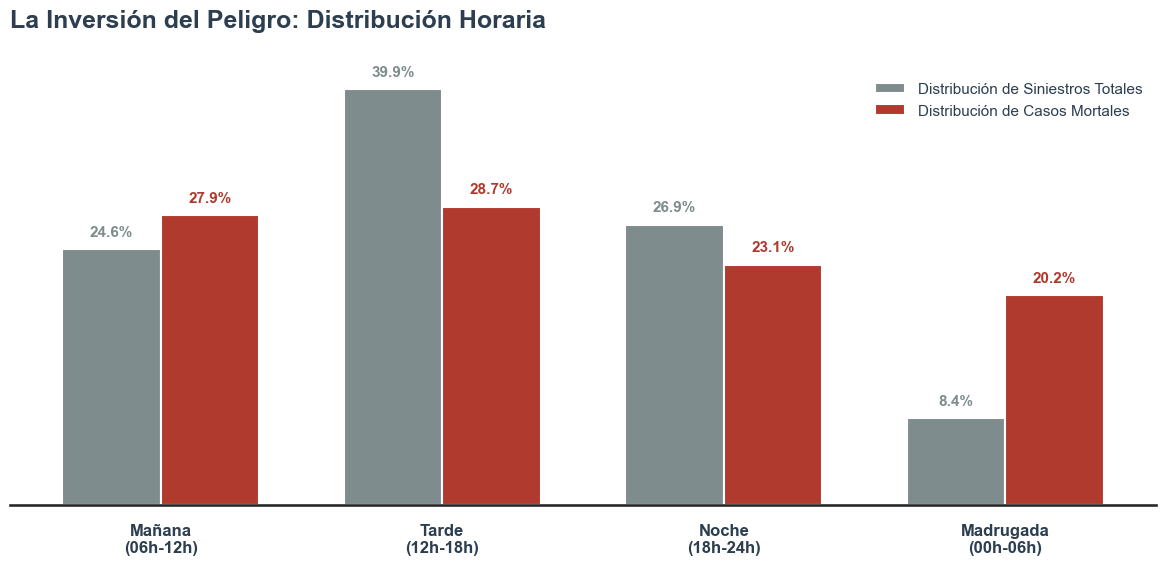

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def graficar_inversion_horaria(df):
    """
    Genera un gráfico de barras agrupadas comparando la distribución porcentual 
    del volumen total vs. la letalidad por franja horaria.
    """
    # 1. Preparación de datos (Asumiendo que tienes una columna 'franja_horaria')
    # Las categorías basadas en tu heatmap
    franjas = ['1. Mañana (06h-12h)', '2. Tarde (12h-18h)', 
               '3. Noche (18h-24h)', '4. Madrugada (00h-06h)']
               
    # Agrupamos por franja y gravedad
    df_horario = df.groupby(['franja_horaria', 'gravedad_victima']).size().unstack(fill_value=0)
    
    # Calculamos los totales
    volumen_absoluto = df_horario.sum(axis=1)
    mortales_absolutos = df_horario.get('MORTAL', pd.Series([0]*len(volumen_absoluto), index=volumen_absoluto.index))
    
    # 2. El paso clave: Normalización (Porcentaje de Distribución)
    # ¿Qué porcentaje del TOTAL de choques ocurre en cada franja?
    pct_volumen = (volumen_absoluto / volumen_absoluto.sum()) * 100
    # ¿Qué porcentaje de las MUERTES ocurre en cada franja?
    pct_mortales = (mortales_absolutos / mortales_absolutos.sum()) * 100
    
    # Filtramos y ordenamos para asegurar que coincidan con nuestra lista de franjas
    pct_volumen = pct_volumen.reindex(franjas).fillna(0)
    pct_mortales = pct_mortales.reindex(franjas).fillna(0)

    # 3. Configuración de Estilo
    plt.style.use('default')
    sns.set_theme(style="white", context="talk")
    
    COLOR_BASAL = '#7F8C8D'
    COLOR_MORTAL = '#B03A2E'
    COLOR_TEXTO = '#2C3E50'
    
    fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
    ax.set_facecolor('white')
    
    # Posicionamiento de las barras agrupadas
    x = np.arange(len(franjas))
    ancho_barra = 0.35
    
    # Barras de Volumen Total (Izquierda de cada grupo)
    barras_vol = ax.bar(x - ancho_barra/2, pct_volumen, ancho_barra, 
                        label='Distribución de Siniestros Totales', color=COLOR_BASAL)
    
    # Barras de Casos Mortales (Derecha de cada grupo)
    barras_mort = ax.bar(x + ancho_barra/2, pct_mortales, ancho_barra, 
                         label='Distribución de Casos Mortales', color=COLOR_MORTAL)
    
    # 4. Etiquetas de datos precisas sobre cada barra
    def agregar_etiquetas(barras, color):
        for barra in barras:
            altura = barra.get_height()
            ax.text(barra.get_x() + barra.get_width()/2., altura + 1,
                    f'{altura:.1f}%', ha='center', va='bottom', 
                    color=color, fontweight='bold', fontsize=11)

    agregar_etiquetas(barras_vol, COLOR_BASAL)
    agregar_etiquetas(barras_mort, COLOR_MORTAL)

    # 5. Estética y limpieza visual
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_yaxis().set_visible(False) # Ocultamos eje Y numérico (ya tenemos las etiquetas)
    
    # Limpiamos los nombres del eje X para que sean más estéticos
    nombres_limpios = ['Mañana\n(06h-12h)', 'Tarde\n(12h-18h)', 'Noche\n(18h-24h)', 'Madrugada\n(00h-06h)']
    ax.set_xticks(x)
    ax.set_xticklabels(nombres_limpios, color=COLOR_TEXTO, fontweight='bold', fontsize=12)
    
    # Leyenda limpia en la parte superior derecha
    ax.legend(frameon=False, loc='upper right', fontsize=11, labelcolor=COLOR_TEXTO)
    
    plt.title('La Inversión del Peligro: Distribución Horaria', 
              fontsize=18, fontweight='bold', color=COLOR_TEXTO, pad=30, loc='left')
    
    plt.tight_layout()
    plt.show()

# Ejecutar función
graficar_inversion_horaria(df)

### Codificacion Label Encoding para ser ingestado en los modelos y exportacion 

In [13]:
# 2_ingenieria_caracteristicas.ipynb - Bloque 5: Imputación y Exportación

from sklearn.impute import SimpleImputer
from pathlib import Path

logger.info("Aplicando imputación a variables numéricas y exportando datos crudos para modelado.")

# Imputación simple para cualquier valor numérico faltante
imputer = SimpleImputer(strategy='median')
num_cols = df.select_dtypes(include=[np.number]).columns
if len(num_cols) > 0:
    df[num_cols] = imputer.fit_transform(df[num_cols])
    logger.info("Imputación mediana aplicada a variables numéricas.")

# GESTIÓN DE RUTAS Y EXPORTACIÓN (Sin Label Encoding)
BASE_DIR = Path.cwd().parent 
processed_dir = BASE_DIR / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)
output_path = processed_dir / 'datos_modelo.csv'

df.to_csv(output_path, index=False)
logger.info(f"Archivo exportado correctamente con textos originales en: {output_path}")
